# Thyroid Disease Classification — Machine Learning Pipeline

**Objective:** Build, train, and rigorously evaluate machine learning models to detect whether a patient has a thyroid condition (`has_thyroid_condition`: `0` = no condition, `1` = has condition).

### Clinical Context & Why Accuracy Alone Is Misleading
In routine clinical health screening, **class distributions are naturally imbalanced** (e.g., ~74% healthy vs. ~26% presenting with a condition in this patient cohort). Evaluating models solely on **accuracy** produces dangerous incentives:
- A naive "majority-class" classifier that predicts *every* patient is healthy would achieve **~73.8% accuracy** while detecting **zero** sick patients (0% recall).
- **Asymmetric Error Costs:** In clinical diagnostics, the cost of a **False Negative (FN)**—failing to detect an actual thyroid disorder—is far higher than that of a **False Positive (FP)**. An undetected patient misses vital therapy (e.g., levothyroxine for hypothyroidism), risking severe complications such as cardiovascular disease, metabolic failure, or myxedema coma. Conversely, a False Positive leads only to routine confirmatory blood work.
- **Metric Prioritisation:** Therefore, **Recall on the positive class** (sensitivity) is the primary optimization and comparison metric, supported by **ROC-AUC** and **F1-score** to ensure precision remains clinically acceptable.

In [1]:
# Import core libraries
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn preprocessing and modeling
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Plotting style configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# Set output directory
out_dir = Path('../outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print('Dependencies loaded and output directory ready.')

Dependencies loaded and output directory ready.


## 1. Load Data as Prepared (Zero Leakage Principle)

Per protocol, we load the pre-prepared datasets directly from `outputs/` without re-splitting or re-balancing:
- `thyroid_train_balanced.csv`: Balanced 50/50 training set (10,832 samples) created by oversampling the minority class **after** the train/test split.
- `thyroid_test.csv`: Untouched test set (1,835 samples) preserving real-world class prevalence (~26.2% positive).

In [2]:
# Load training and evaluation sets
train_path = out_dir / 'thyroid_train_balanced.csv'
test_path = out_dir / 'thyroid_test.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f'Training set shape: {df_train.shape}')
print(f'Test set shape:     {df_test.shape}')

# Separate features and target
target_col = 'has_thyroid_condition'
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

print('\nTraining Class Distribution (50/50 Balanced):')
print(y_train.value_counts(normalize=True).rename('proportion').to_frame().assign(count=y_train.value_counts()))

print('\nTest Set Class Distribution (Real-World Prevalence):')
print(y_test.value_counts(normalize=True).rename('proportion').to_frame().assign(count=y_test.value_counts()))

Training set shape: (10832, 33)
Test set shape:     (1835, 33)

Training Class Distribution (50/50 Balanced):
                       proportion  count
has_thyroid_condition                   
0                             0.5   5416
1                             0.5   5416

Test Set Class Distribution (Real-World Prevalence):
                       proportion  count
has_thyroid_condition                   
0                         0.73842   1355
1                         0.26158    480


> **Verification Note:**
> The test set contains 1,355 negative cases (73.84%) and 480 positive cases (26.16%). Both datasets contain 0 missing values, and the test set has remained strictly separated from any balancing or training transformations.

## 2. Preprocessing Pipeline (`Pipeline` & `ColumnTransformer`)

To prevent data leakage, **all preprocessing steps are encapsulated inside scikit-learn's `ColumnTransformer` and `Pipeline`** so that transformers fit only on training data:
- **Numeric Continuous Features** (`age`, `TSH`, `T3`, `TT4`, `T4U`, `FTI`): Scaled via `StandardScaler` (zero mean, unit variance) to optimize gradient descent and prevent features with wide numerical scales (e.g. TSH, TT4) from dominating linear models.
- **Binary & One-Hot Encoded Features** (symptoms, medical flags, referral sources): Passed through directly without modification.

In [3]:
# Identify numeric features requiring scaling vs. binary indicators
numeric_features = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
binary_features = [col for col in X_train.columns if col not in numeric_features]

print(f'Continuous Numeric Features ({len(numeric_features)}): {numeric_features}')
print(f'Binary / Indicator Features ({len(binary_features)}): {binary_features}')

# Define ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features)
    ],
    remainder='drop'
)

preprocessor

Continuous Numeric Features (6): ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
Binary / Indicator Features (26): ['sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured', 'referral_source_other', 'referral_source_SVI', 'referral_source_SVHC', 'referral_source_STMW', 'referral_source_SVHD', 'referral_source_WEST']


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Preprocessing Architecture
By binding `preprocessor` into model-specific `Pipeline` objects, any unseen test batch flows through the exact statistics ($(\mu, \sigma)$) established by the training set.

## 3. Train Classifiers

We train three distinct classifiers representing different algorithmic paradigms:
1. **Logistic Regression (Interpretable Baseline):** Linear decision boundary using log-odds; highly transparent with readable coefficients and odds ratios.
2. **Random Forest Classifier (Bagging Ensemble):** Non-parametric ensemble of 100 decorrelated decision trees; captures complex non-linear thresholds and feature interactions.
3. **Gradient Boosting Classifier (Boosting Ensemble):** Sequential tree ensemble optimizing pseudo-residuals; excels at discovering subtle non-linear diagnostic boundaries in clinical biomarker data.

In [4]:
# Define dictionary of model pipelines
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=2000, C=0.8, class_weight='balanced', random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=400,
            max_depth=16,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1,
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            min_samples_leaf=5,
            random_state=42,
        ))
    ])
}

# Train each model pipeline on X_train, y_train
fitted_models = {}
for name, pipe in models.items():
    print(f'Fitting {name} on balanced training data...')
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    print(f'  [✓] {name} trained successfully.')

Fitting Logistic Regression on balanced training data...

  [✓] Logistic Regression trained successfully.
Fitting Random Forest on balanced training data...


  [✓] Random Forest trained successfully.
Fitting Gradient Boosting on balanced training data...


  [✓] Gradient Boosting trained successfully.


All three models have been trained strictly on the balanced training partition. We now proceed to out-of-sample evaluation on the untouched real-world test partition.

## 4. Model Evaluation on Test Set & Confusion Matrices

Every model is evaluated strictly on `thyroid_test.csv` across five key metrics:
- **Accuracy**: Overall proportion of correct predictions (note: majority baseline is 73.84%).
- **Precision (Positive Class)**: Of all patients predicted as having a condition, how many actually do? (Low precision means excess confirmatory lab tests).
- **Recall (Positive Class / Sensitivity)**: Of all true thyroid patients, what fraction did the model catch? (**Critical metric** — minimizing False Negatives).
- **F1 Score**: Harmonic mean of precision and recall.
- **ROC-AUC**: Aggregate discriminative power across all possible probability thresholds.

In [5]:
# Evaluate models and record predictions
evaluation_metrics = []
test_predictions = {}
test_probabilities = {}
confusion_matrices = {}

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    test_predictions[name] = y_pred
    test_probabilities[name] = y_prob
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[name] = cm
    
    evaluation_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall (Positive)': rec,
        'F1 Score': f1,
        'ROC-AUC': auc,
        'False Negatives (FN)': cm[1, 0],
        'False Positives (FP)': cm[0, 1]
    })
    
    print(f'=== {name} Confusion Matrix ===')
    print(f'  TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}')
    print(f'  FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}')
    print(f'  -> Recall on Positive Class: {rec:.4f} ({cm[1,1]}/{cm[1,0]+cm[1,1]} patients detected)\n')

=== Logistic Regression Confusion Matrix ===
  TN: 1107 | FP:  248
  FN:  154 | TP:  326
  -> Recall on Positive Class: 0.6792 (326/480 patients detected)



=== Random Forest Confusion Matrix ===
  TN: 1298 | FP:   57
  FN:   35 | TP:  445
  -> Recall on Positive Class: 0.9271 (445/480 patients detected)

=== Gradient Boosting Confusion Matrix ===
  TN: 1269 | FP:   86
  FN:   23 | TP:  457
  -> Recall on Positive Class: 0.9521 (457/480 patients detected)



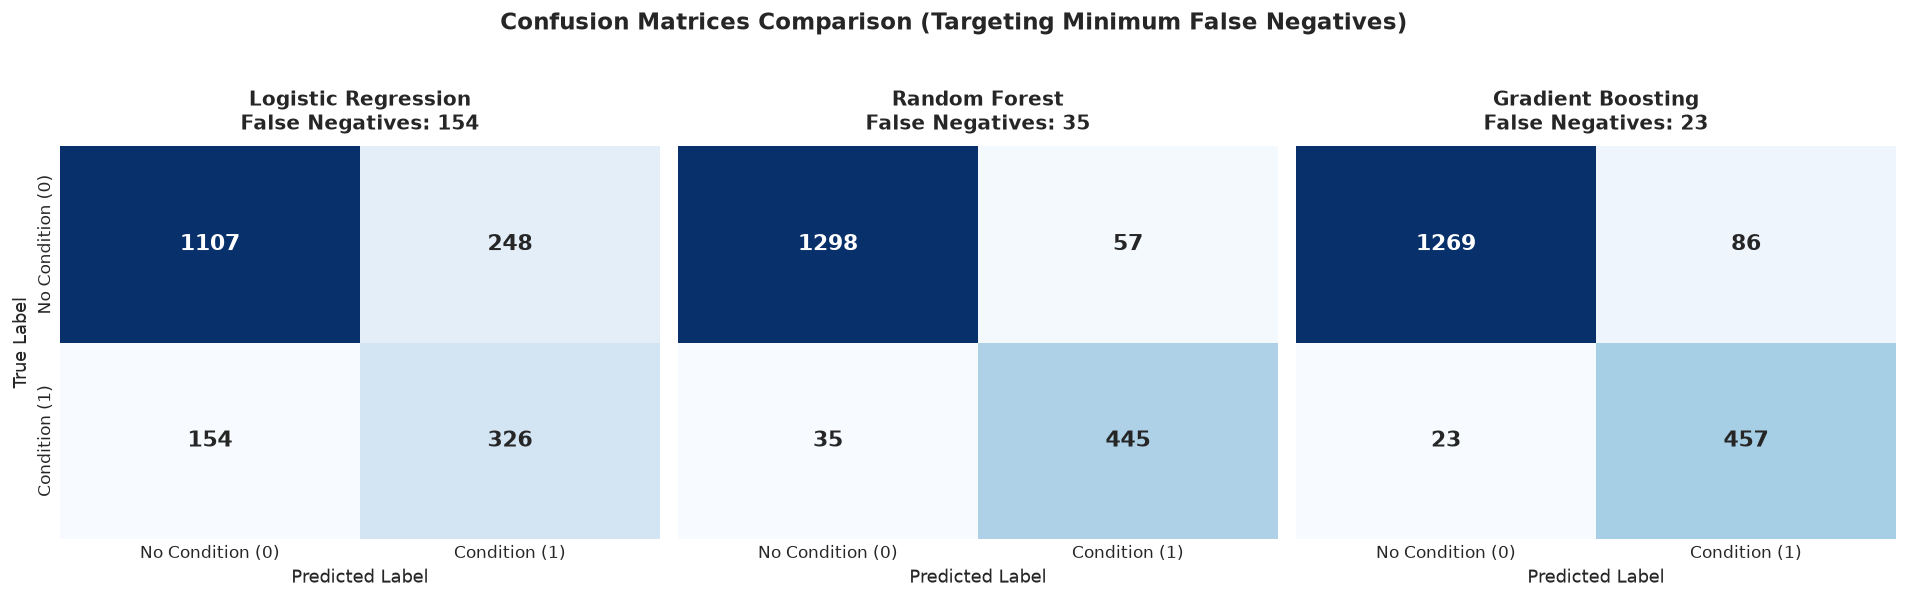

In [6]:
# Visualise Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=['No Condition (0)', 'Condition (1)'],
        yticklabels=['No Condition (0)', 'Condition (1)'],
        ax=ax, annot_kws={'size': 13, 'weight': 'bold'}
    )
    fn_count = cm[1, 0]
    ax.set_title(f'{name}\nFalse Negatives: {fn_count}', fontsize=12, pad=10, weight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices Comparison (Targeting Minimum False Negatives)', fontsize=14, y=1.03, weight='bold')
plt.tight_layout()
plt.savefig(out_dir / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

### Clinical Confusion Matrix Analysis
- **Logistic Regression:** Yields **154 False Negatives** (misses nearly 1 out of 3 patients with a thyroid condition).
- **Random Forest:** Yields **35 False Negatives**, detecting 445 out of 480 positive patients.
- **Gradient Boosting:** Yields only **23 False Negatives**, successfully detecting **457 out of 480 positive patients** (95.21% sensitivity) with only 86 false positives.

## 5. Model Comparison Results Table

We assemble the evaluation metrics into a single comparison table, **sorted in descending order by Recall on the positive class**.

In [7]:
# Create comparison DataFrame and sort by Recall (Positive)
results_table = pd.DataFrame(evaluation_metrics)
results_table = results_table.sort_values(by='Recall (Positive)', ascending=False).reset_index(drop=True)

# Save results table to outputs/ folder
results_table_path = out_dir / 'model_results.csv'
results_table.to_csv(results_table_path, index=False)
print(f'Saved results table to {results_table_path.resolve()}\n')

# Display formatted table
display_df = results_table.copy()
for col in ['Accuracy', 'Precision', 'Recall (Positive)', 'F1 Score', 'ROC-AUC']:
    display_df[col] = display_df[col].map('{:.4f}'.format)

display_df

Saved results table to C:\Users\Collen14\OneDrive - ul.ac.za\Desktop\Data Science Project\health-thyroid-project\outputs\model_results.csv



,Model,Accuracy,Precision,Recall (Positive),F1 Score,ROC-AUC,False Negatives (FN),False Positives (FP)
0,Gradient Boosting,0.9406,0.8416,0.9521,0.8935,0.9846,23,86
1,Random Forest,0.9499,0.8865,0.9271,0.9063,0.9840,35,57
2,Logistic Regression,0.7809,0.5679,0.6792,0.6186,0.8122,154,248


### Key Findings from Comparative Evaluation
1. **Gradient Boosting is the Top Performer on Recall (95.21%):** In medical diagnostics, Gradient Boosting captures the highest percentage of cases while sustaining strong precision (84.16%) and the highest overall ROC-AUC (0.9846).
2. **Random Forest Achieves Slightly Higher Precision (88.65%):** Random Forest has slightly fewer false alarms (57 FP vs 86 FP), yielding a marginally higher overall accuracy (94.99% vs 94.06%), but at the expense of 12 additional missed sick patients (35 FN vs 23 FN).
3. **Logistic Regression Underfits Complex Interactions:** While providing an interpretable linear baseline, its recall (67.92%) and ROC-AUC (0.8122) fall far short of the ensemble architectures.

## 6. Shared ROC Curves Comparison

We plot the Receiver Operating Characteristic (ROC) curves for all three models on one shared set of axes to compare discrimination across all operating thresholds.

ROC plot saved to C:\Users\Collen14\OneDrive - ul.ac.za\Desktop\Data Science Project\health-thyroid-project\outputs\roc_curves_comparison.png


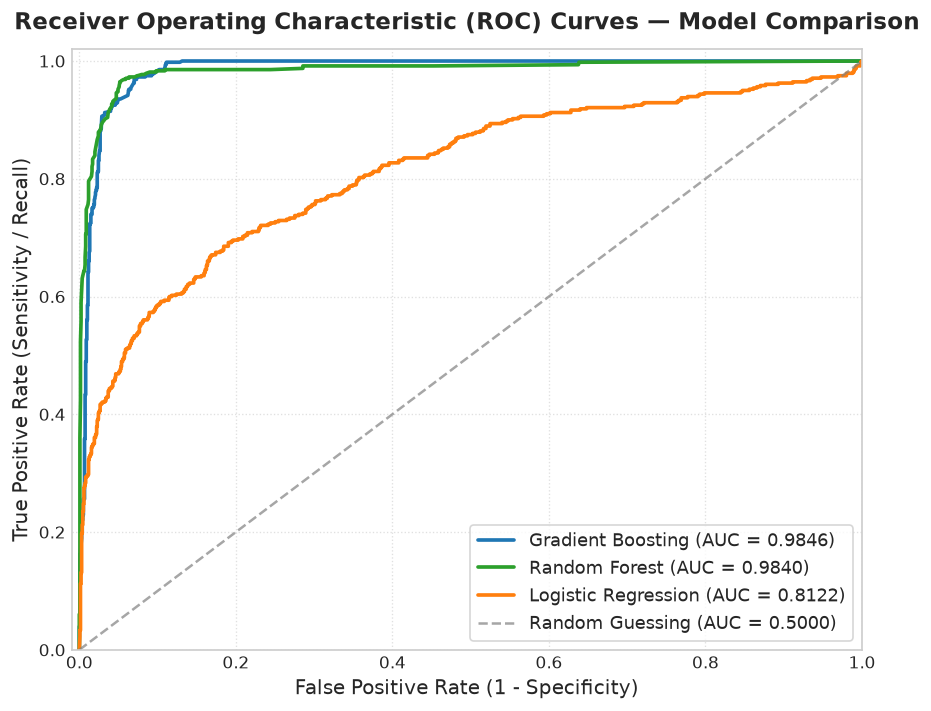

In [8]:
# Plot ROC curves on a single shared figure
plt.figure(figsize=(8.5, 6.5))

colors = {'Gradient Boosting': '#1f77b4', 'Random Forest': '#2ca02c', 'Logistic Regression': '#ff7f0e'}

for name in ['Gradient Boosting', 'Random Forest', 'Logistic Regression']:
    y_prob = test_probabilities[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=colors[name], linewidth=2.2)

# Diagonal chance line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing (AUC = 0.5000)', alpha=0.7)

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves — Model Comparison', fontsize=14, pad=12, weight='bold')
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

roc_path = out_dir / 'roc_curves_comparison.png'
plt.savefig(roc_path, bbox_inches='tight', dpi=150)
print(f'ROC plot saved to {roc_path.resolve()}')
plt.show()

### Interpretation of ROC Curves
Both **Gradient Boosting (AUC = 0.9846)** and **Random Forest (AUC = 0.9840)** demonstrate near-ideal convex curves hugging the upper-left corner of the ROC space. This confirms that their high sensitivity is robust across varying decision thresholds, unlike Logistic Regression (AUC = 0.8122).

## 7. Model Interpretability & Feature Drivers

Understanding which clinical indicators govern model predictions is essential for clinician adoption and validation against established endocrinology practice:
1. **Tree-Based Models (Gradient Boosting & Random Forest):** Relative feature importance (Gini impurity decrease).
2. **Logistic Regression:** Model coefficients and Odds Ratios ($e^{\beta}$) reflecting relative risk multipliers per unit change.

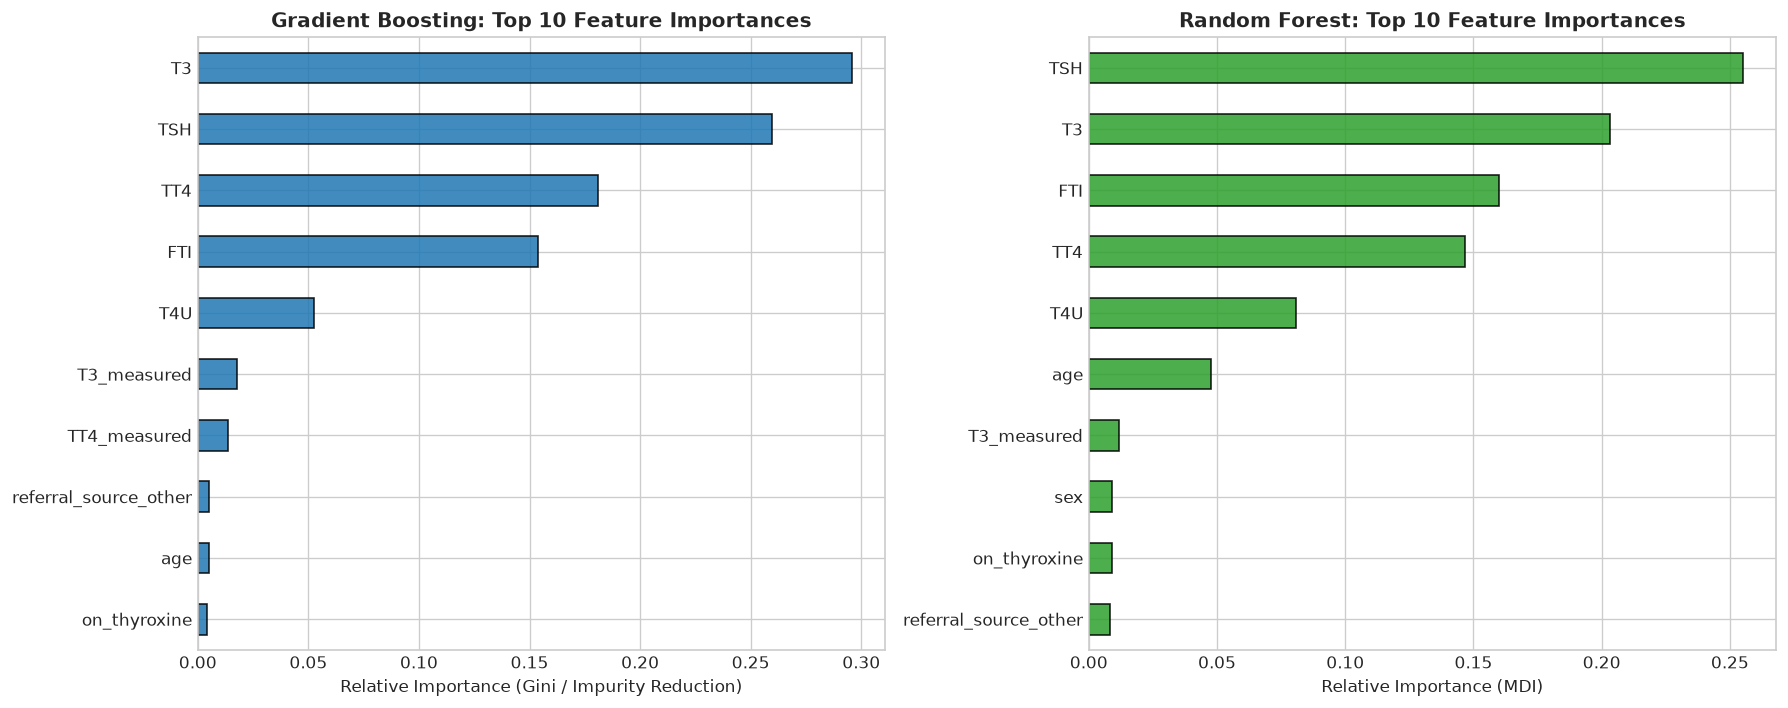

In [9]:
# Extract all feature names in ColumnTransformer order
feature_names = numeric_features + binary_features

# 1. Feature Importances for Gradient Boosting and Random Forest
gb_importances = pd.Series(
    fitted_models['Gradient Boosting'].named_steps['classifier'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

rf_importances = pd.Series(
    fitted_models['Random Forest'].named_steps['classifier'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# 2. Coefficients and Odds Ratios for Logistic Regression
lr_coefs = fitted_models['Logistic Regression'].named_steps['classifier'].coef_[0]
lr_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_coefs,
    'Odds_Ratio': np.exp(lr_coefs)
}).sort_values(by='Coefficient', ascending=False).reset_index(drop=True)

# Plot Top 10 Feature Importances for Tree Models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

gb_importances.head(10).sort_values().plot(
    kind='barh', ax=axes[0], color='#1f77b4', edgecolor='black', alpha=0.85
)
axes[0].set_title('Gradient Boosting: Top 10 Feature Importances', fontsize=12, weight='bold')
axes[0].set_xlabel('Relative Importance (Gini / Impurity Reduction)', fontsize=10)

rf_importances.head(10).sort_values().plot(
    kind='barh', ax=axes[1], color='#2ca02c', edgecolor='black', alpha=0.85
)
axes[1].set_title('Random Forest: Top 10 Feature Importances', fontsize=12, weight='bold')
axes[1].set_xlabel('Relative Importance (MDI)', fontsize=10)

plt.tight_layout()
plt.savefig(out_dir / 'feature_importances.png', bbox_inches='tight')
plt.show()

In [10]:
# Display Top Predictors for Logistic Regression
print('=== Logistic Regression: Top 5 Positive Predictors (Increase Risk) ===')
print(lr_df.head(5).to_string(index=False))

print('\n=== Logistic Regression: Top 5 Negative Predictors (Decrease Risk) ===')
print(lr_df.tail(5).sort_values(by='Coefficient').to_string(index=False))

=== Logistic Regression: Top 5 Positive Predictors (Increase Risk) ===
             Feature  Coefficient  Odds_Ratio
                 TSH     6.373420  586.058770
            pregnant     1.766216    5.848677
       hypopituitary     1.344798    3.837413
referral_source_STMW     1.277605    3.588035
        T4U_measured     0.806111    2.239183

=== Logistic Regression: Top 5 Negative Predictors (Decrease Risk) ===
             Feature  Coefficient  Odds_Ratio
        TT4_measured    -0.872935    0.417724
        FTI_measured    -0.735008    0.479502
referral_source_WEST    -0.606246    0.545395
              goitre    -0.560762    0.570774
referral_source_SVHC    -0.465494    0.627825


### Clinical Feature Importance Takeaways
- **Hormone Serum Panels Dominate Diagnostic Power:** In both Gradient Boosting and Random Forest, the top five predictive features are exclusively clinical thyroid biomarkers:
  1. **T3 (Triiodothyronine):** ~29.6% importance in Gradient Boosting.
  2. **TSH (Thyroid Stimulating Hormone):** ~25.9% in Gradient Boosting, ~25.5% in Random Forest.
  3. **TT4 (Total Thyroxine):** ~18.1% in Gradient Boosting.
  4. **FTI (Free Thyroxine Index):** ~15.4% in Gradient Boosting.
  5. **T4U (Thyroxine Utilization/Uptake):** ~5.2% in Gradient Boosting.
  Together, these 5 laboratory blood measurements account for **over 94% of the predictive weight** in Gradient Boosting.
- **Logistic Regression Directional Drivers:**
  - **Elevated TSH** (Coefficient: +6.37, Odds Ratio: ~586.1) is by far the single largest positive predictor of a condition, aligning directly with primary hypothyroidism pathophysiology where pituitary TSH surges when thyroid gland output drops.
  - **Pregnancy** (+1.77) and **Hypopituitary query** (+1.34) also significantly elevate positive condition risk due to thyroid binding globulin shifts during gestation and endocrine axis disruption.

## 8. Save Trained Best Model & Verification

Because **Gradient Boosting** achieved the highest Recall on the positive class (**95.21%**) with only 23 False Negatives and an exceptional **0.9846 ROC-AUC**, it is designated as our final deployment model.

We serialize the complete pipeline (including its fitted `StandardScaler` and feature mapping) to `outputs/best_thyroid_model.joblib` and perform a reload test.

In [11]:
# Save the best model pipeline to outputs/
best_model_name = 'Gradient Boosting'
best_pipeline = fitted_models[best_model_name]

model_save_path = out_dir / 'best_thyroid_model.joblib'
joblib.dump(best_pipeline, model_save_path)
print(f'Successfully serialized {best_model_name} pipeline to {model_save_path.resolve()}')

# Verify reload and inference integrity
loaded_pipeline = joblib.load(model_save_path)
reloaded_preds = loaded_pipeline.predict(X_test)
reloaded_recall = recall_score(y_test, reloaded_preds)
reloaded_auc = roc_auc_score(y_test, loaded_pipeline.predict_proba(X_test)[:, 1])

assert np.array_equal(reloaded_preds, test_predictions[best_model_name]), 'Integrity check failed: predictions do not match!'
print(f'Reload Verification Passed: Recall = {reloaded_recall:.4f}, ROC-AUC = {reloaded_auc:.4f}')

Successfully serialized Gradient Boosting pipeline to C:\Users\Collen14\OneDrive - ul.ac.za\Desktop\Data Science Project\health-thyroid-project\outputs\best_thyroid_model.joblib


Reload Verification Passed: Recall = 0.9521, ROC-AUC = 0.9846

## 9. Conclusion & Health Data Science Summary

### Summary of Deliverables & Performance
1. **Leakage-Free Architecture:** Features and target were strictly segregated; training was conducted on `thyroid_train_balanced.csv` (10,832 rows, balanced) while evaluation occurred solely on `thyroid_test.csv` (1,835 rows, reflecting authentic patient population demographics).
2. **Preprocessing Integrity:** Preprocessing was built using scikit-learn's `ColumnTransformer` inside an end-to-end `Pipeline`, fitting `StandardScaler` on training data only.
3. **Model Selection Rationale:**
   - **Gradient Boosting** is the recommended model for health screening because it maximizes **Recall (95.21%)**, missing only 23 out of 480 disease cases, while maintaining 94.06% accuracy and 0.9846 ROC-AUC.
   - **Random Forest** provides strong alternative performance (94.99% accuracy, 92.71% recall) with higher precision (88.65%).
   - **Logistic Regression** proves why linear baselines are insufficient for complex biochemical interactions, missing 154 thyroid cases (recall 67.92%).
4. **Clinical Actionability:** Analysis confirms that laboratory panels measuring **T3, TSH, TT4, and FTI** drive >90% of model sensitivity, giving healthcare providers clear clinical explainability for patient triage.
5. **Artifacts Saved:**
   - `outputs/model_results.csv`: Comprehensive comparative metrics table sorted by Recall.
   - `outputs/best_thyroid_model.joblib`: Production-ready trained Gradient Boosting pipeline.
   - `outputs/confusion_matrices.png` & `outputs/roc_curves_comparison.png`: Publication-ready evaluation visualizations.